# Conditional VAE on Fashion-MNIST

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(device)

IMAGE_DIM = 28 * 28
NUM_CLASSES = 10
LATENT_DIM = 20
HIDDEN_DIM = 400
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3

CLASS_NAMES = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

mps


## Data

In [2]:
transform = transforms.ToTensor()

train_data = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print(len(train_data), len(test_data))

100.0%
100.0%
100.0%
100.0%

60000 10000


## Model

In [3]:
def labels_to_onehot(labels):
    return F.one_hot(labels, NUM_CLASSES).float()


class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(IMAGE_DIM + NUM_CLASSES, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
        )
        self.mu = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM + NUM_CLASSES, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, IMAGE_DIM),
            nn.Sigmoid(),
        )

    def encode(self, x, y):
        h = self.encoder(torch.cat([x, y], dim=1))
        return self.mu(h), self.logvar(h)

    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, y):
        return self.decoder(torch.cat([z, y], dim=1))

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.sample(mu, logvar)
        return self.decode(z, y), mu, logvar


model = CVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print(sum(p.numel() for p in model.parameters()))

981624


## Train

epoch 1: 285.65
epoch 2: 251.44
epoch 3: 246.27
epoch 4: 243.84
epoch 5: 242.06
epoch 6: 240.91
epoch 7: 239.91
epoch 8: 239.17
epoch 9: 238.47
epoch 10: 238.05


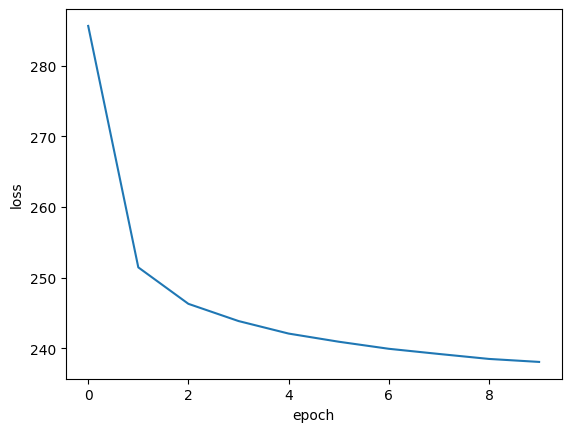

In [4]:
def loss_fn(recon, x, mu, logvar):
    bce = F.binary_cross_entropy(recon, x, reduction="sum")
    kld = -0.5 * torch.sum(1 + logvar - mu.square() - logvar.exp())
    return bce + kld


losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, labels in train_loader:
        x = x.view(x.size(0), -1).to(device)
        y = labels_to_onehot(labels).to(device)

        recon, mu, logvar = model(x, y)
        loss = loss_fn(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_data)
    losses.append(avg_loss)
    print(f"epoch {epoch + 1}: {avg_loss:.2f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

## Reconstruct

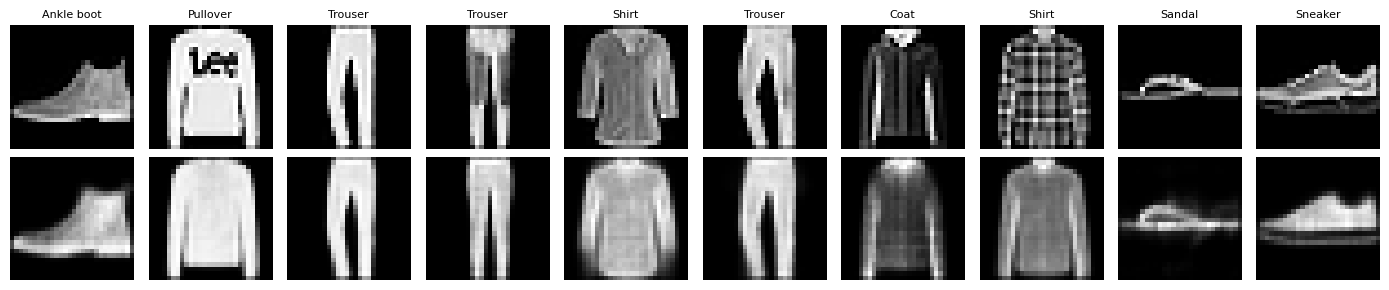

In [5]:
model.eval()
x, labels = next(iter(test_loader))
x = x[:10].to(device)
y = labels_to_onehot(labels[:10]).to(device)

with torch.no_grad():
    recon, _, _ = model(x.view(10, -1), y)

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(x[i].cpu().squeeze(), cmap="gray")
    axes[0, i].set_title(CLASS_NAMES[labels[i]], fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("real")
axes[1, 0].set_ylabel("recon")
plt.tight_layout()
plt.show()

## Generate

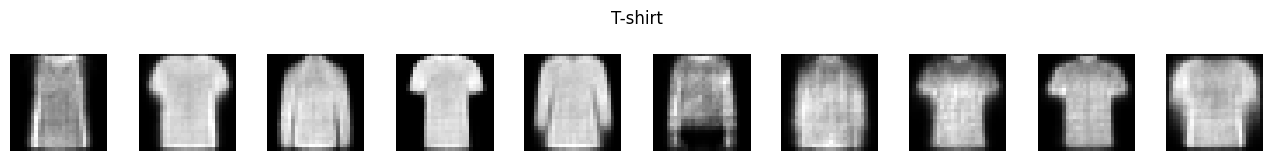

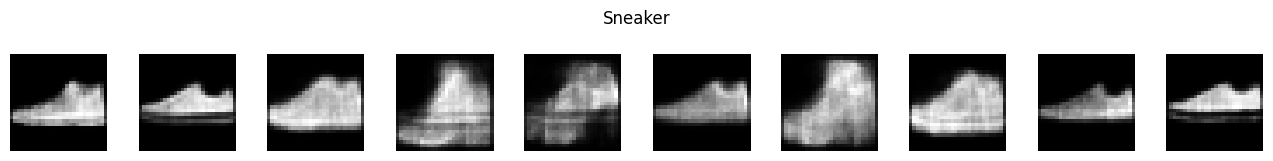

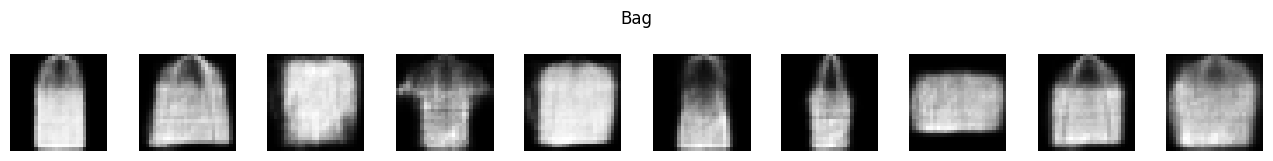

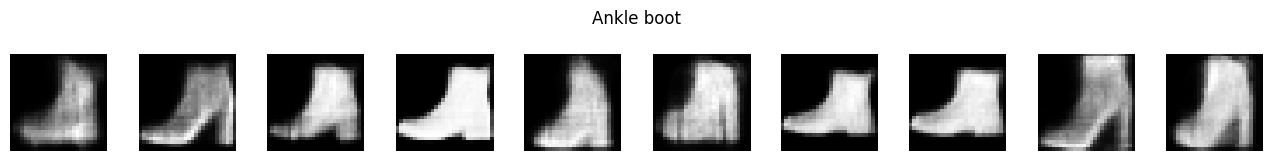

In [6]:
def generate(class_idx, n=10):
    z = torch.randn(n, LATENT_DIM, device=device)
    labels = torch.full((n,), class_idx, dtype=torch.long)
    y = labels_to_onehot(labels).to(device)
    with torch.no_grad():
        return model.decode(z, y).cpu().view(n, 28, 28)


def show_generated(class_idx, n=10):
    imgs = generate(class_idx, n)
    fig, axes = plt.subplots(1, n, figsize=(1.3 * n, 1.6))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i], cmap="gray")
        ax.axis("off")
    plt.suptitle(CLASS_NAMES[class_idx])
    plt.tight_layout()
    plt.show()


for class_idx in [0, 7, 8, 9]:
    show_generated(class_idx)